In [2]:
import copy
import numpy as np
from corsair import units
from corsair.optimization.variable import Variable
from corsair.optimization import Formulation, Constant

cst = Constant(name = 'c', value = 2.0 + 1/2, units = '-', size = 0, description = 'A constant')

x1 = Variable(name = 'x_1', 
              guess = 0.0, 
              units = '-', 
              size = 0, 
              description = 'Quantity of product 1')

x2 = Variable(name = 'x_2', 
              guess = 0.0, 
              units = '-', 
              size = 0, 
              description = 'Quantity of product 2')

obj = -(3 * cst*x1 + 3.4 * x2)
cons = [
    3   * x1 + 4    * x2 <= 20000 + 2000,
    0.3 * x1 + 0.38 * x2 <= 4000 - 400,
    x1 >= 0,
    x2 >= 0
]

f = Formulation(obj, cons)
from corsair.optimization.solve import solve
rs = solve(f)
rs.computeSensitivities()
print(rs.result(3))

ModuleNotFoundError: No module named 'corsair'

In [ ]:
import copy
import numpy as np
from corsair import units
from corsair.optimization import Variable
from corsair.optimization import Formulation, Constant

cst = Constant(name = 'c', value = 3.0, units = '-', size = 0, description = 'A constant')
x   = Variable(name = 'x', guess = 1.0, units = '-', size = 0, description = 'The X variable')
y   = Variable(name = 'y', guess = 2.0, units = '-', size = 0, description = 'The Y variable')
c2 = Constant(name = 'c2', value = 2, units = '-', size = 0, description = 'A constant')

obj = x**2 + 4*y**c2 - 8*x - 16*y +1 + x*y
cons = [
    x + y <= 5,
    x <= 3,
    x >= 0,
    y >= 0,
    x + y == cst,
]

f = Formulation(obj, cons)
from corsair.optimization.solve import solve
f.solverOptions.solveType = 'qp'
f.solverOptions.solver = 'cvxopt'
# print(f.substitute())
rs = solve(f)
rs.computeSensitivities()
# print(rs.rawResult)
# print(rs['x'])
print(rs.result(5))


Objective
---------
   -21.56250 dimensionless

Variables
---------
   x  :  1.62500   [-]   The X variable
   y  :  1.37500   [-]   The Y variable

Constants
---------
   c   :  3         [-]   A constant
   c2  :  2         [-]   A constant

Sensitivities
-------------
   c   :  + 0.46957   A constant
   c2  :  - 0.22338   A constant

Solve Report
------------
   Solve Method           :  Quadratic Program 
   Classification         :  Convex 
   Solver                 :  cvxopt 



In [ ]:
import copy
import numpy as np
from corsair import units
from corsair.optimization.variable import Variable
from corsair.optimization import Formulation, Constant

x   = Variable(name = 'x', guess = 1.0, units = '-', size = 0, description = 'The X variable')
y   = Variable(name = 'y', guess = 2.0, units = '-', size = 0, description = 'The Y variable')
z   = Variable(name = 'z', guess = 3.0, units = '-', size = 0, description = 'The Z variable')
cst = Constant(name = 'c', value = 2.0, units = '-', size = 0, description = 'A constant')

objective = x*z/y
constraints = [
    2.0 <= x,
    x <= 3,
    x**2 >= y**0.5,
    x/y == z**2
              ]

f = Formulation(objective, constraints)
# print(f.variables)
# f.setZero()
# print(f.toZeroed())
# print(f.substitute())
# print(f.substitute({'x': 2.0*units.dimensionless}))
# print(f.table())
# print(f.generateTable())
from corsair.optimization.solve import solve
f.solverOptions.solveType = 'gp'
rs = solve(f)
# print(rs)
# print(rs['x'])
print(rs.result(5))
# print(rs.variables)


Objective
---------
   0.00713 dimensionless

Variables
---------
   x  :   3.00000   [-]   The X variable
   y  :  81.00009   [-]   The Y variable
   z  :   0.19245   [-]   The Z variable

Sensitivities
-------------
   No Constants in the Formulation

Solve Report
------------
   Solve Method           :  Geometric Program 
   Classification         :  Convex 
   Solver                 :  cvxopt 



In [ ]:
from corsair.optimization import Variable, Constant, Formulation

w   = Variable(name = 'w', guess = 1.0, units = 'm', description = 'The X variable')
h   = Variable(name = 'h', guess = 1.0, units = 'm', description = 'The Y variable')
d   = Variable(name = 'd', guess = 1.0, units = 'm', description = 'The Z variable')

Aflr  = Constant(name = 'Aflr',  value = 1000  , units = 'm^2', description = 'Area of floor')
Awall = Constant(name = 'Awall', value =  100  , units = 'm^2', description = 'Area of wall')
alpha = Constant(name = 'alpha', value =    0.5, units = '-',   description = 'Aspect Ratio Constraint')
beta  = Constant(name = 'beta',  value =    2  , units = '-',   description = 'Aspect Ratio Constraint')
gamma = Constant(name = 'gamma', value =    0.5, units = '-',   description = 'Aspect Ratio Constraint')
delta = Constant(name = 'delta', value =    2  , units = '-',   description = 'Aspect Ratio Constraint')

objective = 1/(h*w*d)
constraints = [
    2*(h*w + h*d) <= Awall,
    w*d <= Aflr,
    alpha <= h/w,
    h/w <= beta,
    gamma <= d/w,
    d/w <= delta,
              ]

f = Formulation(objective, constraints)
from corsair.optimization.solve import solve
f.solverOptions.solveType = 'gp'
rs = solve(f)
print(rs.result(5))


Objective
---------
   0.00520 1 / meter ** 3

Variables
---------
   d  :  11.54644   meter   The Z variable
   h  :   2.88682   meter   The Y variable
   w  :   5.77364   meter   The X variable

Constants
---------
   Aflr   :  1000         meter ** 2   Area of floor          
   Awall  :   100         meter ** 2   Area of wall           
   alpha  :     0.50000      [-]       Aspect Ratio Constraint
   beta   :     2            [-]       Aspect Ratio Constraint
   delta  :     2            [-]       Aspect Ratio Constraint
   gamma  :     0.50000      [-]       Aspect Ratio Constraint

Sensitivities
-------------
   Sensitivities not computed

Solve Report
------------
   Solve Method           :  Geometric Program 
   Classification         :  Convex 
   Solver                 :  cvxopt 



In [ ]:
import numpy as np
pi = np.pi
from corsair import units
from corsair.optimization.variable import Variable
from corsair.optimization import Formulation, Constant

# Constants
flp         = Constant(name = "flp",    value = -1.0,     units ="-",      description = "flipper")
k           = Constant(name = "k",      value = 1.2,     units ="-",      description = "form factor")
e           = Constant(name = "e",      value = 0.95,    units ="-",      description = "Oswald efficiency factor")
mu          = Constant(name = "mu",     value = 1.78e-5, units ="kg/m/s", description = "viscosity of air")
rho         = Constant(name = "rho",    value = 1.23,    units ="kg/m^3", description = "density of air")
tau         = Constant(name = "tau",    value = 0.12,    units ="-",      description = "airfoil thickness to chord ratio")
N_ult       = Constant(name = "N_ult",  value = 3.8,     units ="-",      description = "ultimate load factor")
V_min       = Constant(name = "V_min",  value = 22,      units ="m/s",    description = "takeoff speed")
C_Lmax      = Constant(name = "C_Lmax", value = 1.5,     units ="-",      description = "max CL with flaps down")
S_wetratio  = Constant(name = "Srat",   value = 2.05,    units ="-",      description = "wetted area ratio")
W_W_coeff1  = Constant(name = "W_c1",   value = 8.71e-5, units ="1/m",    description = "Wing Weight Coefficent 1")
W_W_coeff2  = Constant(name = "W_c2",   value = 45.24,   units ="Pa",     description = "Wing Weight Coefficent 2")
CDA0        = Constant(name = "CDA0",   value = 0.031,   units ="m^2",    description = "fuselage drag area")
W_0         = Constant(name = "W_0",    value = 4940.0,  units ="N",      description = "aircraft weight excluding wing")

# Free Variables
D   = Variable(name = "D",   guess = 300.0, units = "N",   description = "total drag force")
A   = Variable(name = "A",   guess = 8.0, units = "-",   description = "aspect ratio")
S   = Variable(name = "S",   guess = 16.0, units = "m^2", description = "total wing area")
V   = Variable(name = "V",   guess = 39.0, units = "m/s", description = "cruising speed")
W   = Variable(name = "W",   guess = 10000.0, units = "N",   description = "total aircraft weight")
Re  = Variable(name = "Re",  guess = .36e7, units = "-",   description = "Reynold's number")
C_D = Variable(name = "C_D", guess = .025, units = "-",   description = "Drag coefficient of wing")
C_L = Variable(name = "C_L", guess = .5, units = "-",   description = "Lift coefficent of wing")
C_f = Variable(name = "C_f", guess = .003, units = "-",   description = "skin friction coefficient")
W_w = Variable(name = "W_w", guess = 2400, units = "N",   description = "wing weight")


cre = Constant('cre',0.2,'','Reynolds Exponent')
constraints = []

C_D_fuse = CDA0/S
C_D_wpar = k*C_f*S_wetratio
C_D_ind = C_L**2/(pi*A*e)
W_w_strc = W_W_coeff1*(N_ult*A**1.5*(W_0*W*S)**0.5)/tau
W_w_surf = W_W_coeff2 * S

constraints += [C_D >= C_D_fuse + C_D_wpar + C_D_ind,
                W_w >= W_w_surf + W_w_strc,
                D >= 0.5*rho*S*C_D*V**2,
                Re == (rho/mu)*V*(S/A)**0.5,
                C_f == 0.074/Re**cre,
                W == 0.5*rho*S*C_L*V**2,
                W == 0.5*rho*S*C_Lmax*V_min**2,
                W >= W_0 + W_w,
               ]
f = Formulation(D, constraints)
zeroed = f.toZeroed()
subbed = zeroed.substitute()


# 
# print(f.table())
from corsair.optimization.solve import solve
# rs = solve(f)
# # print(rs)
# print(rs.result(7))
# rs2 = solve(f,'ga','deap', lowerBound = .8, upperBound=1.2, initialPopulationSize=10000, minIter=10, maxIter= 12, feasibilityCost = 100000)
# rs2 = solve(f, trustRegions = {'C_D':0.1, 'S':0.1, 'C_f':0.1, 'C_L':0.1, 'A':0.1}, returnRaw = True)
# rs2 = solve(f, trustRegions = {'C_D':0.1}, returnRaw=True)
f.solverOptions.solveType = 'gp'
f.solverOptions.solver = 'cvxopt'
rs2 = solve(f)
print(rs2.result(7))


Objective
---------
   303.0662562 newton

Variables
---------
   A    :        8.4600054        [-]         aspect ratio             
   C_D  :        0.0205919        [-]         Drag coefficient of wing 
   C_L  :        0.4987901        [-]         Lift coefficent of wing  
   C_f  :        0.0035989        [-]         skin friction coefficient
   D    :      303.0662559       newton       total drag force         
   Re   :  3675217.6468534        [-]         Reynold's number         
   S    :       16.4417392     meter ** 2     total wing area          
   V    :       38.1513054   meter / second   cruising speed           
   W    :     7341.0720904       newton       total aircraft weight    
   W_w  :     2401.0875236       newton       wing weight              

Constants
---------
   CDA0    :     0.0310000           meter ** 2          fuselage drag area              
   C_Lmax  :     1.5000000              [-]              max CL with flaps down          
   N_ult   :   

In [ ]:
import copy
import numpy as np
from corsair import units
from corsair.optimization.variable import Variable
from corsair.optimization import Formulation, Constant

x   = Variable(name = 'x', guess = 1, units = '-', size = 0, description = 'The X variable')
y   = Variable(name = 'y', guess = 1, units = '-', size = 0, description = 'The Y variable')
z   = Variable(name = 'z', guess = 1, units = '-', size = 0, description = 'The Z variable')
cst = Constant(name = 'c', value = 2.0, units = '-', size = 0, description = 'A constant')

objective = x*z/y
constraints = [
    cst <= x,
    x <= 3,
    x**2 >= y,
    x/y == z/3,
    y == 4 + x,
              ]

f = Formulation(objective, constraints)
from corsair.optimization.solve import solve
f.solverOptions.solveType = 'sp'
f.solverOptions.solver = 'cvxopt'
# f.solverOptions.tol = 1e-8
rs = solve(f)
print(rs.result(5))
# print(rs.__dict__.keys())
# print(len(rs.intermediateSolves))


Objective
---------
   0.45721 dimensionless

Variables
---------
   x  :  2.56155   [-]   The X variable
   y  :  6.56155   [-]   The Y variable
   z  :  1.17116   [-]   The Z variable

Constants
---------
   c  :  2         [-]   A constant

Sensitivities
-------------
   c  :    0.00001   A constant

Solve Report
------------
   Solve Method           :  Signomial Program--Standard 
   Classification         :  Iterative 
   Solver                 :  cvxopt 
   Number of Iterations   :  2 
   Termination Status     :  Converged, relative error (3.15e-04) is less than specified tolerance (1.00e-03) 



In [ ]:
# import copy
# import numpy as np
# from corsair import units
# from corsair.optimization.variable import Variable
# from corsair.optimization import Formulation, Constant

# x   = Variable(name = 'x', guess = 1, units = '-', size = 0, description = 'The X variable')
# y   = Variable(name = 'y', guess = 1, units = '-', size = 0, description = 'The Y variable')
# z   = Variable(name = 'z', guess = 1, units = '-', size = 0, description = 'The Z variable')
# cst = Constant(name = 'c', value = 2.0, units = '-', size = 0, description = 'A constant')

# objective = x/y
# constraints = [
#     y <= 3 + x ,
#     y >= 10
#               ]

# f = Formulation(objective, constraints)
# from corsair.optimization.solve import solve
# f.solverOptions.solveType = 'sp'
# f.solverOptions.solver = 'cvxopt'
# # f.solverOptions.tol = 1e-8
# rs = solve(f)
# rs.computeSensitivities()
# print(rs.result(5))
# # print(rs.__dict__.keys())
# # print(len(rs.intermediateSolves))









# =================
# Import Statements
# =================
import numpy as np
import pyomo
from pyomo.contrib.edi import Formulation
from pyomo.environ import units


# ===================
# Declare Formulation
# ===================
f = Formulation()

# =================
# Declare Variables
# =================
x   = f.Variable(name = 'x', guess = 1, units = '-', size = 0, description = 'The X variable')
y   = f.Variable(name = 'y', guess = 1, units = '-', size = 0, description = 'The Y variable')
# z   = f.Variable(name = 'z', guess = 1, units = '-', size = 0, description = 'The Z variable')
cst = f.Constant(name = 'c', value = 2.0, units = '-', size = 0, description = 'A constant')


# =====================
# Declare the Objective
# =====================
f.Objective(x**2/y)

# =======================
# Declare the Constraints
# =======================
Constraints = []

Constraints += [ 
        y <= 1 + x ,
        x >= 2
                ]

f.ConstraintList(Constraints)

var_list = f.get_variables()
    
# f.pprint()
from solver import cvxopt_solve
res = cvxopt_solve(f)
# print(res)

# import pyomo.environ as pyo
# opt = pyo.SolverFactory('ipopt')
# opt.solve(f)
#Uncomment only if solving with ipopt

var_list = f.get_variables()
ctr = 0
for var in var_list:
    #print(type(var))
    if isinstance(var,pyomo.core.base.var.IndexedVar):
        # print('%s:  %s'%(var.name,var._units))
        # print(var[0].value)
        # print(var.index_set())
        for ix in var.index_set():
            lbls = ["out","ret","sprint"]
            print('%s[%s]:  %.4f  %s'%(var.name,lbls[ix],res['x'][ctr],var._units))
            ctr += 1
    else:
        print('%s:  %.4f  %s'%(var.name,res['x'][ctr],var._units))
        ctr += 1


{'status': 'optimal', 'primal objective': 1.4142130694361508, 'dual objective': 1.4142135623730856, 'x': <5x1 matrix, tc='d'>, 'y': <0x1 matrix, tc='i'>, 'z': <6x1 matrix, tc='d'>, 's': <5x1 matrix, tc='d'>, 'N_cons_total': 2, 'N_cons_noBounds': 2, 'N_cons_bounds': 0, 'inequality_unscramble': [0, 1, 2, 3, 4, 5], 'equality_unscramble': []}
[ 2.00e+00]
[ 2.83e+00]
[ 1.00e+00]
[ 1.00e+00]
[ 1.00e+00]

{'status': 'optimal', 'primal objective': 1.3333329001228016, 'dual objective': 1.3333333333333248, 'x': <5x1 matrix, tc='d'>, 'y': <0x1 matrix, tc='i'>, 'z': <6x1 matrix, tc='d'>, 's': <5x1 matrix, tc='d'>, 'N_cons_total': 2, 'N_cons_noBounds': 2, 'N_cons_bounds': 0, 'inequality_unscramble': [0, 1, 2, 3, 4, 5], 'equality_unscramble': []}
[ 2.00e+00]
[ 3.00e+00]
[ 1.00e+00]
[ 1.00e+00]
[ 1.00e+00]

{'status': 'optimal', 'primal objective': 1.3333329001228027, 'dual objective': 1.3333333333333257, 'x': <5x1 matrix, tc='d'>, 'y': <0x1 matrix, tc='i'>, 'z': <6x1 matrix, tc='d'>, 's': <5x1 matri

1.9155408290138962

In [ ]:
# import time
# t = time.time()
import numpy as np
pi = np.pi
# from corsair import units
# from corsair.optimization.variable import Variable
# from corsair.optimization import Formulation, Constant

import numpy as np
import pyomo
from pyomo.contrib.edi import Formulation
from pyomo.environ import units
f = Formulation()




# Constants
k           = f.Constant(name = "k",      value = 1.2,     units ="-",      description = "form factor")
e           = f.Constant(name = "e",      value = 0.95,    units ="-",      description = "Oswald efficiency factor")
mu          = f.Constant(name = "mu",     value = 1.78e-5, units ="kg/m/s", description = "viscosity of air")
rho         = f.Constant(name = "rho",    value = 1.23,    units ="kg/m^3", description = "density of air")
tau         = f.Constant(name = "tau",    value = 0.12,    units ="-",      description = "airfoil thickness to chord ratio")
N_ult       = f.Constant(name = "N_ult",  value = 3.8,     units ="-",      description = "ultimate load factor")
V_min       = f.Constant(name = "V_min",  value = 22,      units ="m/s",    description = "takeoff speed")
C_Lmax      = f.Constant(name = "C_Lmax", value = 1.5,     units ="-",      description = "max CL with flaps down")
S_wetratio  = f.Constant(name = "Srat",   value = 2.05,    units ="-",      description = "wetted area ratio")
W_W_coeff1  = f.Constant(name = "W_c1",   value = 8.71e-5, units ="1/m",    description = "Wing Weight Coefficent 1")
W_W_coeff2  = f.Constant(name = "W_c2",   value = 45.24,   units ="Pa",     description = "Wing Weight Coefficent 2")
CDA0        = f.Constant(name = "CDA0",   value = 0.031,   units ="m^2",    description = "fuselage drag area")
W_0         = f.Constant(name = "W_0",    value = 4940.0,  units ="N",      description = "aircraft weight excluding wing")

# Free Variables
D   = f.Variable(name = "D",   guess = 300.0, units = "N",   description = "total drag force")
A   = f.Variable(name = "A",   guess = 8.0, units = "-",   description = "aspect ratio")
S   = f.Variable(name = "S",   guess = 16.0, units = "m^2", description = "total wing area")
V   = f.Variable(name = "V",   guess = 39.0, units = "m/s", description = "cruising speed")
W   = f.Variable(name = "W",   guess = 10000.0, units = "N",   description = "total aircraft weight")
Re  = f.Variable(name = "Re",  guess = .36e7, units = "-",   description = "Reynold's number")
C_D = f.Variable(name = "C_D", guess = .025, units = "-",   description = "Drag coefficient of wing")
C_L = f.Variable(name = "C_L", guess = .5, units = "-",   description = "Lift coefficent of wing")
C_f = f.Variable(name = "C_f", guess = .003, units = "-",   description = "skin friction coefficient")
W_w = f.Variable(name = "W_w", guess = 2400, units = "N",   description = "wing weight")

constraints = []

# Drag model
C_D_fuse = CDA0/S
C_D_wpar = k*C_f*S_wetratio
C_D_ind = C_L**2/(pi*A*e)
constraints += [C_D >= C_D_fuse + C_D_wpar + C_D_ind] #Note the use of equality here

# Wing weight model
W_w_strc = W_W_coeff1*(N_ult*A**1.5*(W_0*W*S)**0.5)/tau
W_w_surf = W_W_coeff2 * S
constraints += [
    W_w >= W_w_surf + W_w_strc
]

# and the rest of the models
constraints += [D >= 100,
                D >= 0.5*rho*S*C_D*V**2,
                Re <= (rho/mu)*V*(S/A)**0.5,
                C_f >= 0.074/Re**0.2,
                W <= 0.5*rho*S*C_L*V**2,
                W <= 0.5*rho*S*C_Lmax*V_min**2,
                W >= W_0 + W_w,
               ]


f.ConstraintList(constraints)
f.Objective(D)

var_list = f.get_variables()
    
# f.pprint()
from solver import cvxopt_solve
res = cvxopt_solve(f)
# print(res)

# import pyomo.environ as pyo
# opt = pyo.SolverFactory('ipopt')
# opt.solve(f)
#Uncomment only if solving with ipopt

var_list = f.get_variables()
ctr = 0
for var in var_list:
    #print(type(var))
    if isinstance(var,pyomo.core.base.var.IndexedVar):
        # print('%s:  %s'%(var.name,var._units))
        # print(var[0].value)
        # print(var.index_set())
        for ix in var.index_set():
            lbls = ["out","ret","sprint"]
            print('%s[%s]:  %.4f  %s'%(var.name,lbls[ix],res['x'][ctr],var._units))
            ctr += 1
    else:
        print('%s:  %.4f  %s'%(var.name,res['x'][ctr],var._units))
        ctr += 1






# f = Formulation(D, constraints)

# from corsair.optimization.solve import solve
# import time
# t = time.time()
# # opts = solverOptions()
# # opts.solveType = 'gp'
# # opts.solver='cvxopt'
# rs2 = solve(f)
# print(rs2.result())
# print('   Runtime  :  %.2f'%(time.time()-t))

D:  303.0747  N
A:  8.4600  dimensionless
S:  16.4418  m**2
V:  38.1514  m/s
W:  7341.0966  N
Re:  3675233.3607  dimensionless
C_D:  0.0206  dimensionless
C_L:  0.4988  dimensionless
C_f:  0.0036  dimensionless
W_w:  2401.0968  N


In [ ]:
import copy
import numpy as np
from corsair import units
from corsair.optimization.variable import Variable
from corsair.optimization import Formulation, Constant

x   = Variable(name = 'x', guess = 1.0, units = 'm', size = 0, type_=float, bounds=[-4,4], description = 'The X variable')
y   = Variable(name = 'y', guess = 1.0, units = 'm', size = 0, type_=float, bounds=[-4,4], description = 'The Y variable')

objective = x**2 + y**2
constraints = [
    x >= 2.0*units.m,
    y >= 2.0*units.m,
              ]

f = Formulation(objective, constraints)
from corsair.optimization.solve import solve
f.solverOptions.solveType = 'nms'; f.solverOptions.solver = 'corsair'
# f.solverOptions.greedy ='minimization'
rs = solve(f)
print(rs.result(2))


Objective
---------
   8.00 meter ** 2

Variables
---------
   x  :  2.00   meter   The X variable
   y  :  2.00   meter   The Y variable

Sensitivities
-------------
   Sensitivities not available for optimizations of type Nelder-Mead Simplex 

Solve Report
------------
   Solve Method           :  Nelder-Mead Simplex 
   Classification         :  Heuristic 
   Solver                 :  corsair 
   Number of Iterations   :  53 
   Termination Status     :  Converged, simplex function values are sufficiently close (tol=1.00e-04) 
   Feasibility            :  Yes 



In [ ]:
import numpy as np
pi = np.pi
from corsair import units
from corsair.optimization.variable import Variable
from corsair.optimization import Formulation, Constant

# Constants
flp         = Constant(name = "flp",    value = -1.0,     units ="-",      description = "flipper")
k           = Constant(name = "k",      value = 1.2,     units ="-",      description = "form factor")
e           = Constant(name = "e",      value = 0.95,    units ="-",      description = "Oswald efficiency factor")
mu          = Constant(name = "mu",     value = 1.78e-5, units ="kg/m/s", description = "viscosity of air")
rho         = Constant(name = "rho",    value = 1.23,    units ="kg/m^3", description = "density of air")
tau         = Constant(name = "tau",    value = 0.12,    units ="-",      description = "airfoil thickness to chord ratio")
N_ult       = Constant(name = "N_ult",  value = 3.8,     units ="-",      description = "ultimate load factor")
V_min       = Constant(name = "V_min",  value = 22,      units ="m/s",    description = "takeoff speed")
C_Lmax      = Constant(name = "C_Lmax", value = 1.5,     units ="-",      description = "max CL with flaps down")
S_wetratio  = Constant(name = "Srat",   value = 2.05,    units ="-",      description = "wetted area ratio")
W_W_coeff1  = Constant(name = "W_c1",   value = 8.71e-5, units ="1/m",    description = "Wing Weight Coefficent 1")
W_W_coeff2  = Constant(name = "W_c2",   value = 45.24,   units ="Pa",     description = "Wing Weight Coefficent 2")
CDA0        = Constant(name = "CDA0",   value = 0.031,   units ="m^2",    description = "fuselage drag area")
W_0         = Constant(name = "W_0",    value = 4940.0,  units ="N",      description = "aircraft weight excluding wing")

# Free Variables
D   = Variable(name = "D",   guess = 300.0, units = "N",   description = "total drag force")
A   = Variable(name = "A",   guess = 8.0, units = "-",   description = "aspect ratio")
S   = Variable(name = "S",   guess = 16.0, units = "m^2", description = "total wing area")
V   = Variable(name = "V",   guess = 39.0, units = "m/s", description = "cruising speed")
W   = Variable(name = "W",   guess = 10000.0, units = "N",   description = "total aircraft weight")
Re  = Variable(name = "Re",  guess = .36e7, units = "-",   description = "Reynold's number")
C_D = Variable(name = "C_D", guess = .025, units = "-",   description = "Drag coefficient of wing")
C_L = Variable(name = "C_L", guess = .5, units = "-",   description = "Lift coefficent of wing")
C_f = Variable(name = "C_f", guess = .003, units = "-",   description = "skin friction coefficient")
W_w = Variable(name = "W_w", guess = 2400, units = "N",   description = "wing weight")


cre = Constant('cre',0.2,'','Reynolds Exponent')
constraints = []

# Drag model
C_D_fuse = CDA0/S
C_D_wpar = k*C_f*S_wetratio
C_D_ind = C_L**2/(pi*A*e)
constraints += [C_D >= C_D_fuse + C_D_wpar + C_D_ind]
# constraints += [C_D  ==  34.354 * S**-0.000 * C_f**0.000 * C_L**2.000 * A**-1.000, 44.444 * C_D  <=  1.100, 44.444 * C_D  >=  0.900]
# constraints += [0.032 * V  <=  1.200*units.m/units.sec, 0.032 * V  >=  0.800*units.m/units.sec]

# constraints += [C_D >= 0.01]

# Wing weight model
W_w_strc = W_W_coeff1*(N_ult*A**1.5*(W_0*W*S)**0.5)/tau
W_w_surf = W_W_coeff2 * S
constraints += [
    W_w >= W_w_surf + W_w_strc
]

# and the rest of the models
constraints += [D >= 0.5*rho*S*C_D*V**2,
                Re == (rho/mu)*V*(S/A)**0.5,
                C_f == 0.074/Re**0.2,
                W == 0.5*rho*S*C_L*V**2,
                W == 0.5*rho*S*C_Lmax*V_min**2,
                W >= W_0 + W_w,
               ]
f = Formulation(D, constraints)
f.solverOptions.solveType = 'nms'; f.solverOptions.solver = 'corsair'
from corsair.optimization.solve import solve
import time
t = time.time()
rs2 = solve(f)
print(rs2.result(7))
print('   Runtime  :  %.2f'%(time.time()-t))


Objective
---------
   322.8564144 newton

Variables
---------
   A    :        8.6264934        [-]         aspect ratio             
   C_D  :        0.0204831        [-]         Drag coefficient of wing 
   C_L  :        0.5057210        [-]         Lift coefficent of wing  
   C_f  :        0.0035817        [-]         skin friction coefficient
   D    :      322.8405289       newton       total drag force         
   Re   :  3764291.9355917        [-]         Reynold's number         
   S    :       17.8329777     meter ** 2     total wing area          
   V    :       37.8882234   meter / second   cruising speed           
   W    :     7962.1975338       newton       total aircraft weight    
   W_w  :     3007.2253180       newton       wing weight              

Constants
---------
   CDA0    :     0.0310000           meter ** 2          fuselage drag area              
   C_Lmax  :     1.5000000              [-]              max CL with flaps down          
   N_ult   :   

In [ ]:
import copy
import numpy as np
from corsair import units
from corsair.optimization.variable import Variable
from corsair.optimization import Formulation, Constant

x   = Variable(name = 'x', guess = 1.0, units = 'm', size = 0, type_=float, bounds=[-4,4], description = 'The X variable')

objective = x**2
constraints = [
    x >= 2.0*units.m,
              ]

f = Formulation(objective, constraints)
from corsair.optimization.solve import solve
f.solverOptions.solveType = 'sa'; f.solverOptions.solver = 'corsair'
rs = solve(f)
print(rs.result(2))


Objective
---------
   4.00 meter ** 2

Variables
---------
   x  :  2.00   meter   The X variable

Sensitivities
-------------
   Sensitivities not available for optimizations of type Simulated Annealing 

Solve Report
------------
   Solve Method           :  Simulated Annealing 
   Classification         :  Heuristic 
   Solver                 :  corsair 
   Number of Trials       :  1000 
   Feasibility            :  Yes 



In [ ]:
import copy
import numpy as np
from corsair import units
from corsair.optimization.variable import Variable
from corsair.optimization import Formulation, Constant

x   = Variable(name = 'x', guess = 1.0, units = 'm', size = 0, type_=float, bounds=[-4,4], description = 'The X variable')

objective = x**2
constraints = [
    x >= 2.0*units.m,
              ]

f = Formulation(objective, constraints)
from corsair.optimization.solve import solve
f.solverOptions.solveType = 'pso'; f.solverOptions.solver = 'corsair'
rs = solve(f)
print(rs.result(2))


Objective
---------
   4.00 meter ** 2

Variables
---------
   x  :  2.00   meter   The X variable

Sensitivities
-------------
   Sensitivities not available for optimizations of type Particle Swarm Optimization 

Solve Report
------------
   Solve Method           :  Particle Swarm Optimization 
   Classification         :  Heuristic 
   Solver                 :  corsair 
   Number of Time Steps   :  51 
   Swarm Size             :  20 
   Termination Status     :  Converged, Result Constant for 5 Time Steps (tol=1.00e-06) 
   Feasibility            :  Yes 



In [ ]:
import copy
import numpy as np
from corsair import units
from corsair.optimization.variable import Variable
from corsair.optimization import Formulation, Constant

x   = Variable(name = 'x', guess = 1.0, units = 'm', size = 0, type_=float, bounds=[-4,4], description = 'The X variable')

objective = x**2
constraints = [
    x >= 2.0*units.m,
              ]

f = Formulation(objective, constraints)
from corsair.optimization.solve import solve
f.solverOptions.solveType = 'ga'; f.solverOptions.solver = 'corsair'
rs = solve(f)
print(rs.result(2))


Objective
---------
   4.00 meter ** 2

Variables
---------
   x  :  2      meter   The X variable

Sensitivities
-------------
   Sensitivities not available for optimizations of type Genetic Algorithm 

Solve Report
------------
   Solve Method           :  Genetic Algorithm 
   Classification         :  Heuristic 
   Solver                 :  corsair 
   Number of Generations  :  34 
   Population Size        :  20 
   Termination Status     :  Converged, result constant within relative tolerance of tol=1.00e-06 for 20 generations 
   Feasibility            :  Yes 



In [ ]:
import copy
import numpy as np
from corsair import units
from corsair.optimization import Variable
from corsair.optimization import Formulation, Constant

x   = Variable(name = 'x', guess = 1.0, units = 'm', size = 0, description = 'The X variable')
y   = Variable(name = 'y', guess = 2.0, units = 'm', size = 0, description = 'The Y variable')
cst = Constant(name = 'c', value = 2.0, units = '-', size = 0, description = 'A constant')

objective = x**2 + y**2
constraints = [
    x*y**2 >= 1*units.m**3,
#     y >= 2,
              ]

f = Formulation(objective, constraints)
from corsair.optimization.solve import solve
f.solverOptions.solveType = 'gp'
rs = solve(f)
print(rs.result(3))

f.solverOptions.solveType = 'sqp'
f.solverOptions.tol = 1e-6
f.solverOptions.stepSize = 0.8
f.solverOptions.solver = 'mosek'
rs2 = solve(f)
print(rs2.result(3))
# print('   Number of Iterations  :  %d\n'%(len(rs2.intermediateSolves)))

f.solverOptions.solveType = 'lsqp'
f.solverOptions.solver = 'mosek'
rs3 = solve(f)
print(rs3.result(3))
# print('   Number of Iterations  :  %d\n'%(len(rs3.intermediateSolves)))


Objective
---------
   1.890 meter ** 2

Variables
---------
   x  :  0.794   meter   The X variable
   y  :  1.122   meter   The Y variable

Sensitivities
-------------
   No Constants in the Formulation

Solve Report
------------
   Solve Method           :  Geometric Program 
   Classification         :  Convex 
   Solver                 :  cvxopt 

Iteration 0
[1.0999999719311662, 1.2999999719311661]
[0.09090907 0.53846157 0.9753087 ]
Iteration 1
[0.8055588985235643, 1.2397150595709676]
[0.29444107 0.04862804 0.2549288 ]
Iteration 2
[0.8326230563366522, 1.128246888790226]
[0.02706416 0.09879768 0.06021487]
Iteration 3
[0.7869861481087924, 1.1355346596690794]
[0.04563691 0.00641792 0.00672848]
Iteration 4
[0.7994803675905064, 1.1205459085001508]
[1.24942195e-02 1.33762937e-02 7.50782194e-05]
Iteration 5
[0.7920537842546493, 1.1242371111664273]
[7.42658334e-03 3.28329552e-03 9.98220894e-05]
Iteration 6
[0.7945137341004169, 1.1220727432086592]
[2.45994985e-03 1.92890164e-03 2.6681176

In [ ]:
import copy
import numpy as np
from corsair import units
from corsair.optimization import Variable
from corsair.optimization import Formulation, Constant

w   = Variable(name = 'w', guess = 2.0, units = 'm', size = 0, description = 'The X variable')
h   = Variable(name = 'h', guess = 2.0, units = 'm', size = 0, description = 'The Y variable')
d   = Variable(name = 'd', guess = 10.0, units = 'm', size = 0, description = 'The Z variable')

Aflr  = Constant(name = 'Aflr',  value = 1000  , units = 'm^2', size = 0, description = 'Area of floor')
Awall = Constant(name = 'Awall', value =  100  , units = 'm^2', size = 0, description = 'Area of wall')
alpha = Constant(name = 'alpha', value =    0.5, units = '-',   size = 0, description = 'Aspect Ratio Constraint')
beta  = Constant(name = 'beta',  value =    2  , units = '-',   size = 0, description = 'Aspect Ratio Constraint')
gamma = Constant(name = 'gamma', value =    0.5, units = '-',   size = 0, description = 'Aspect Ratio Constraint')
delta = Constant(name = 'delta', value =    2  , units = '-',   size = 0, description = 'Aspect Ratio Constraint')

objective = 1/(h*w*d)
constraints = [
    2*(h*w + h*d) <= Awall,
    w*d <= Aflr,
    alpha <= h/w,
    h/w <= beta,
    gamma <= d/w,
    d/w <= delta,
              ]

f = Formulation(objective, constraints)
from corsair.optimization.solve import solve
f.solverOptions.solveType = 'gp'
rs = solve(f)
print(rs.result(5))

f.solverOptions.solver = 'mosek'
f.solverOptions.solveType = 'sqp'
# f.solverOptions.tol = 0.000001
# f.solverOptions.stepSize = 1.0
# f.solverOptions.stepScheduleBase = 1.0
rs2 = solve(f)
print(rs2.result(5))

f.solverOptions.solveType = 'lsqp'
rs3 = solve(f)
print(rs3.result(5))


Objective
---------
   0.00520 1 / meter ** 3

Variables
---------
   d  :  11.47592   meter   The Z variable
   h  :   2.89568   meter   The Y variable
   w  :   5.79135   meter   The X variable

Constants
---------
   Aflr   :  1000         meter ** 2   Area of floor          
   Awall  :   100         meter ** 2   Area of wall           
   alpha  :     0.50000      [-]       Aspect Ratio Constraint
   beta   :     2            [-]       Aspect Ratio Constraint
   delta  :     2            [-]       Aspect Ratio Constraint
   gamma  :     0.50000      [-]       Aspect Ratio Constraint

Sensitivities
-------------
   Awall  :  - 1.50000   Area of wall           
   alpha  :  + 0.50000   Aspect Ratio Constraint
   delta  :  - 0.00309   Aspect Ratio Constraint
   beta   :    0.00000   Aspect Ratio Constraint
   gamma  :    0.00000   Aspect Ratio Constraint
   Aflr   :    0.00000   Area of floor          

Solve Report
------------
   Solve Method           :  Geometric Program 
   Cla

Error: rescode.err_obj_q_not_psd(1295): The quadratic coefficient matrix in the objective is not positive semidefinite as expected for a minimization problem.

In [ ]:
import copy
import numpy as np
from corsair import units
from corsair.optimization import Variable
from corsair.optimization import Formulation, Constant

x   = Variable(name = 'x', guess = 10.0, units = 'm', size = 0, description = 'The X variable')
y   = Variable(name = 'y', guess = 10.0, units = 'm', size = 0, description = 'The Y variable')
cst = Constant(name = 'c', value = 2.0, units = '-', size = 0, description = 'A constant')

objective = x**2 + y**2
constraints = [
#     x >= 2*units.m,
#     y >= 2*units.m,
    y + x >= 10*units.m + cst*units.m
              ]

f = Formulation(objective, constraints)
from corsair.optimization.solve import solve
f.solverOptions.solveType = 'qp'
rs = solve(f)
print(rs.result(3))

f.solverOptions.solveType = 'sqp'
f.solverOptions.tol = 1e-6
f.solverOptions.stepSize = 0.98
rs2 = solve(f)
print(rs2.result(3))
print('   Number of Iterations  :  %d\n'%(len(rs2.intermediateSolves)))

f.solverOptions.solveType = 'lsqp'
rs3 = solve(f)
print(rs3.result(3))
print('   Number of Iterations  :  %d\n'%(len(rs3.intermediateSolves)))

/Users/codykarcher/software/miniconda3/lib/python3.7/site-packages/ipykernel_launcher.py:19: RuntimeWarning: divide by zero encountered in log
/Users/codykarcher/software/miniconda3/lib/python3.7/site-packages/ipykernel_launcher.py:19: RuntimeWarning: invalid value encountered in log


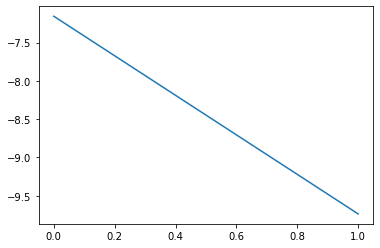

In [ ]:
import dill
from corsair.core.pickleFunctions import setPickle


# setPickle()
# f = open('LSQP_runDirectory/LSQP_progress','rb')
# res = dill.load(f)
# f.close()
# # print(res.gradientOfLagrangian)
# # print(res.steps)
# print(res.objectiveFunctionValues)

import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np

y = np.array([v.magnitude for v in res.objectiveFunctionValues]) - res.objectiveFunctionValues[-1].magnitude
# print(y)
plt.plot(np.log(y))
# plt.ylim([-1.5,-1])

In [ ]:
import copy
import numpy as np
from corsair import units
from corsair.optimization import Variable
from corsair.optimization import Formulation, Constant

w   = Variable(name = 'w', guess = 4.0, units = 'm', size = 0, description = 'The X variable')
h   = Variable(name = 'h', guess = 2.0, units = 'm', size = 0, description = 'The Y variable')
d   = Variable(name = 'd', guess = 10.0, units = 'm', size = 0, description = 'The Z variable')

Aflr  = Constant(name = 'Aflr',  value = 1000  , units = 'm^2', size = 0, description = 'Area of floor')
Awall = Constant(name = 'Awall', value =  100  , units = 'm^2', size = 0, description = 'Area of wall')
alpha = Constant(name = 'alpha', value =    0.5, units = '-',   size = 0, description = 'Aspect Ratio Constraint')
beta  = Constant(name = 'beta',  value =    2  , units = '-',   size = 0, description = 'Aspect Ratio Constraint')
gamma = Constant(name = 'gamma', value =    0.5, units = '-',   size = 0, description = 'Aspect Ratio Constraint')
delta = Constant(name = 'delta', value =    2  , units = '-',   size = 0, description = 'Aspect Ratio Constraint')

objective = 1/(h*w*d)
constraints = [
    2*(h*w + h*d) <= Awall,
    w*d <= Aflr,
    alpha <= h/w,
    h/w <= beta,
    gamma <= d/w,
    d/w <= delta,
              ]

formulation = Formulation(objective, constraints)
formulation.solverOptions.solveType = 'sqp'
formulation.solverOptions.solver = 'cvxopt'
formulation.solverOptions.lagrangianGradientTolerance = 1e-5
from corsair.optimization.solve import solve
rs = solve(formulation)
print(rs.result(5))

formulation = Formulation(objective, constraints)
formulation.solverOptions.solveType = 'lsqp'
formulation.solverOptions.solver = 'cvxopt'
formulation.solverOptions.lagrangianGradientTolerance = 1e-5
formulation.generateSolverOptions()
rs = solve(formulation)
print(rs.result(5))

In [ ]:
import copy
import numpy as np
from corsair import units
from corsair.optimization import Variable, Constant
from corsair.optimization import Formulation, RuntimeConstraint

w     = Variable(name = 'w', guess = 2.0, units = 'm', size = 0, description = 'The X variable')
h     = Variable(name = 'h', guess = 2.0, units = 'm', size = 0, description = 'The Y variable')
d     = Variable(name = 'd', guess = 10.0, units = 'm', size = 0, description = 'The Z variable')
Awall = Variable(name = 'Awall', guess =  100  , units = 'm^2', size = 0, description = 'Area of wall')

Aflr  = Constant(name = 'Aflr',  value = 1000  , units = 'm^2', size = 0, description = 'Area of floor')
# Awall = Constant(name = 'Awall', value =  100  , units = 'm^2', size = 0, description = 'Area of wall')
alpha = Constant(name = 'alpha', value =    0.5, units = '-',   size = 0, description = 'Aspect Ratio Constraint')
beta  = Constant(name = 'beta',  value =    2  , units = '-',   size = 0, description = 'Aspect Ratio Constraint')
gamma = Constant(name = 'gamma', value =    0.5, units = '-',   size = 0, description = 'Aspect Ratio Constraint')
delta = Constant(name = 'delta', value =    2  , units = '-',   size = 0, description = 'Aspect Ratio Constraint')

import os
import copy
import numpy as np
from corsair import units
# from corsair.core.dataTypes.variable import Variable
from corsair.analysis.models.model import Model
    
class AwallComp(Model):
    def __init__(self):
        super(AwallComp, self).__init__()
        self.description = 'This model evaluates the function: A_wall >= 2*(h*w + h*d)'
        self.inputs.append(Variable('h', 1.0, units.m,  'height'))
        self.inputs.append(Variable('w', 1.0, units.m,  'width'))
        self.inputs.append(Variable('d', 1.0, units.m,  'depth'))
        
        self.outputs.append(Variable('A_wall', 1.0, units.m**2,  'Total Wall Area'))
        self.data.inputs = copy.deepcopy(self.inputs)
        self.data.outputs = copy.deepcopy(self.outputs)
        self.availableDerivative = 1
        self.data.availableDerivative = self.availableDerivative
    
    def BlackBox(*args, **kwargs):
        args = list(args)       # convert tuple to list
        self = args.pop(0)      # pop off the self argument
        runCases, returnMode, extra = self.parseInputs(*args, **kwargs)
    
        h = np.array([ runCases[i]['h'].magnitude for i in range(0,len(runCases)) ])
        w = np.array([ runCases[i]['w'].magnitude for i in range(0,len(runCases)) ])
        d = np.array([ runCases[i]['d'].magnitude for i in range(0,len(runCases)) ])
 
        y = 2*(h*w + h*d)
        dydh = 2*w + 2*d
        dydw = 2*h
        dydd = 2*h
        
        self.data.addData({'h': [float(hval)*units.m for hval in h], 
                           'w': [float(wval)*units.m for wval in w], 
                           'd': [float(dval)*units.m for dval in d], 
                           'A_wall': [float(Aval)*units.m**2 for Aval in y], 
                           '__D1':[[[float(dydh[i])*units.m, float(dydw[i])*units.m, float(dydd[i])*units.m]] for i in range(0,len(dydh))]})
        
        y = [ self.checkOutputs(float(yval)*units.m**2) for yval in y ]
        dydx = [[float(dydh[i])*units.m, float(dydw[i])*units.m, float(dydd[i])*units.m] for i in range(0,len(dydh))]

        if returnMode < 0:
            returnMode = -1*(returnMode + 1)
            if returnMode == 0:  return y[0]
            if returnMode == 1:  return y[0], dydx[0]
        else:
            if returnMode == 0:
                opt = []
                for i in range(0,len(y)):
                    opt.append([ y[i] ])
                return opt
            if returnMode == 1:
                opt = []
                for i in range(0,len(y)):
                    opt.append([ [y[i]],  [[dydx[i]]] ] )
                return opt

rtc1 = AwallComp()
            
objective = 1/(h*w*d)
constraints = [
#     RuntimeConstraint( [Awall], ['>='], [h,w,d], rtc1),
#     2*(h*w + h*d) <= Awall,
    w*d <= Aflr,
    alpha <= h/w,
    h/w <= beta,
    gamma <= d/w,
    d/w <= delta,
    Awall == 100*units.m**2
              ]

f = Formulation(objective,  constraints + [2*(h*w + h*d) <= Awall])
# f.solverOptions.solver = 'cvxopt'
# f.solverOptions.solveType = 'sqp'
# f.generateSolverOptions()
# rs = SequentialQuadraticProgramSolver(f)
# print(rs.result(5))

# f2 = Formulation(objective, constraints + [RuntimeConstraint( [Awall], ['>='], [h,w,d], rtc1)])
# f2.solverOptions.solver = 'cvxopt'
# f2.solverOptions.solveType = 'sqp'
# f2.generateSolverOptions()
# rs2 = SequentialQuadraticProgramSolver(f2)


from corsair.optimization.solve import solve
# print()
f2 = Formulation(objective, constraints + [RuntimeConstraint( [Awall], ['>='], [h,w,d], rtc1)])
# f2 = Formulation(objective,  constraints + [2*(h*w + h*d) <= Awall])
f2.solverOptions.solver = 'cvxopt'
f2.solverOptions.solveType = 'sqp'
f2.solverOptions.scaleObjective = True
f2.solverOptions.scaleConstraints = True
f2.solverOptions.scaleVariables = True
f2.generateSolverOptions()
# rs2 = SequentialQuadraticProgramSolver(f2)

# import time
# t = time.time()
rs2 = solve(f2)
# print(time.time() - t)
# print(rs2.result(5))
# print('')
# t = time.time()
# rs2 = SequentialQuadraticProgramSolver(f)
# print(time.time()-t)

# # rs2 = solve(f)
print(rs2.result(5))

In [ ]:
import copy
import numpy as np
from corsair import units
from corsair.optimization import Formulation, Variable, RuntimeConstraint

from corsair.optimization.solve import solve

x   = Variable(name = 'x', guess = 1.0, units = '-', size = 0, description = 'The X variable')
y   = Variable(name = 'y', guess = 2.0, units = '-', size = 0, description = 'The Y variable')

u   = Variable(name = 'u', guess = 1.0, units = '-', size = 0, description = 'The U variable')
v   = Variable(name = 'v', guess = 2.0, units = '-', size = 0, description = 'The V variable')

import os
import copy
import numpy as np
from corsair import units
from corsair.core.dataTypes.variable import Variable
from corsair.analysis.models.model import Model
    
class SignomialTest(Model):
    def __init__(self):
        super(SignomialTest, self).__init__()
        
        self.description = 'This model evaluates the function: y=x**2'
        self.inputs.append(Variable('x', 1.0, units.dimensionless,  'Independent Variable'))
        self.outputs.append(Variable('y', 1.0, units.dimensionless,  'Dependent Variable'))
        self.availableDerivative = 1
        
        self.setupDataContainer()
    
    def BlackBox(*args, **kwargs):
        args = list(args)       # convert tuple to list
        self = args.pop(0)      # pop off the self argument
        runCases, returnMode, extra = self.parseInputs(*args, **kwargs)
        x = [ runCases[i]['x'] for i in range(0,len(runCases)) ]
        x = np.array([ self.sanitizeInputs(xval).to('').magnitude for xval in x ])
        
        y = x**2
        dydx = 2*x
        ddy_ddx = 2
        
        self.data.addData({'x': x.tolist(), 'y': y.tolist(), '__D1':[[[dydx[i]]] for i in range(0,len(dydx))]})
        y = [ self.checkOutputs(yval) for yval in y ]
        dydx = [dydx[i] * units.dimensionless for i in range(0,len(dydx))]
        
        if returnMode < 0:
            returnMode = -1*(returnMode + 1)
            if returnMode == 0:  return y[0]
            if returnMode == 1:  return y[0], dydx
        else:
            if returnMode == 0:
                opt = []
                for i in range(0,len(y)):
                    opt.append([ y[i] ])
                return opt
            if returnMode == 1:
                opt = []
                for i in range(0,len(y)):
                    opt.append([ [y[i]], [ [[dydx[i]]] ] ])
                return opt

s = SignomialTest()

objective = 1/(x*y)
constraints = [
    x**2 + y **2 <= 1,
#     y <= x**2
    RuntimeConstraint([y], ['<='], [x], s)
              ]

f = Formulation(objective, constraints)
f.solverOptions.solver = 'cvxopt'
f.solverOptions.solveType = 'sqp'
f.generateSolverOptions()
rs = SequentialQuadraticProgramSolver(f)
# rs = solve(f)
print(rs.result(5))

In [ ]:
import copy
import numpy as np
from corsair import units
from corsair.optimization import Variable, Constant
from corsair.optimization import Formulation, RuntimeConstraint

w     = Variable(name = 'w', guess = 2.0, units = 'm', size = 0, description = 'The X variable')
h     = Variable(name = 'h', guess = 2.0, units = 'm', size = 0, description = 'The Y variable')
d     = Variable(name = 'd', guess = 10.0, units = 'm', size = 0, description = 'The Z variable')
Awall = Variable(name = 'Awall', guess =  100  , units = 'm^2', size = 0, description = 'Area of wall')

Aflr  = Constant(name = 'Aflr',  value = 1000  , units = 'm^2', size = 0, description = 'Area of floor')
# Awall = Constant(name = 'Awall', value =  100  , units = 'm^2', size = 0, description = 'Area of wall')
alpha = Constant(name = 'alpha', value =    0.5, units = '-',   size = 0, description = 'Aspect Ratio Constraint')
beta  = Constant(name = 'beta',  value =    2  , units = '-',   size = 0, description = 'Aspect Ratio Constraint')
gamma = Constant(name = 'gamma', value =    0.5, units = '-',   size = 0, description = 'Aspect Ratio Constraint')
delta = Constant(name = 'delta', value =    2  , units = '-',   size = 0, description = 'Aspect Ratio Constraint')

import os
import copy
import numpy as np
from corsair import units
# from corsair.core.dataTypes.variable import Variable
from corsair.analysis.models.model import Model
    
class AwallComp(Model):
    def __init__(self):
        super(AwallComp, self).__init__()
        self.description = 'This model evaluates the function: A_wall >= 2*(h*w + h*d)'
        self.inputs.append(Variable('h', 1.0, units.m,  'height'))
        self.inputs.append(Variable('w', 1.0, units.m,  'width'))
        self.inputs.append(Variable('d', 1.0, units.m,  'depth'))
        
        self.outputs.append(Variable('A_wall', 1.0, units.m**2,  'Total Wall Area'))
        self.data.inputs = copy.deepcopy(self.inputs)
        self.data.outputs = copy.deepcopy(self.outputs)
        self.availableDerivative = 1
        self.data.availableDerivative = self.availableDerivative
    
    def BlackBox(*args, **kwargs):
        args = list(args)       # convert tuple to list
        self = args.pop(0)      # pop off the self argument
        runCases, returnMode, extra = self.parseInputs(*args, **kwargs)
    
        h = np.array([ runCases[i]['h'].magnitude for i in range(0,len(runCases)) ])
        w = np.array([ runCases[i]['w'].magnitude for i in range(0,len(runCases)) ])
        d = np.array([ runCases[i]['d'].magnitude for i in range(0,len(runCases)) ])
 
        y = 2*(h*w + h*d)
        dydh = 2*w + 2*d
        dydw = 2*h
        dydd = 2*h
        
        self.data.addData({'h': [float(hval)*units.m for hval in h], 
                           'w': [float(wval)*units.m for wval in w], 
                           'd': [float(dval)*units.m for dval in d], 
                           'A_wall': [float(Aval)*units.m**2 for Aval in y], 
                           '__D1':[[[float(dydh[i])*units.m, float(dydw[i])*units.m, float(dydd[i])*units.m]] for i in range(0,len(dydh))]})
        
        y = [ self.checkOutputs(float(yval)*units.m**2) for yval in y ]
        dydx = [[float(dydh[i])*units.m, float(dydw[i])*units.m, float(dydd[i])*units.m] for i in range(0,len(dydh))]

        if returnMode < 0:
            returnMode = -1*(returnMode + 1)
            if returnMode == 0:  return y[0]
            if returnMode == 1:  return y[0], dydx[0]
        else:
            if returnMode == 0:
                opt = []
                for i in range(0,len(y)):
                    opt.append([ y[i] ])
                return opt
            if returnMode == 1:
                opt = []
                for i in range(0,len(y)):
                    opt.append([ [y[i]],  [[dydx[i]]] ] )
                return opt

rtc1 = AwallComp()
            
objective = 1/(h*w*d)
constraints = [
    w*d <= Aflr,
    alpha <= h/w,
    h/w <= beta,
    gamma <= d/w,
    d/w <= delta,
    Awall == 100*units.m**2
              ]


f1 = Formulation(objective,  constraints + [2*(h*w + h*d) <= Awall])
f1.solverOptions.solver = 'cvxopt'
f1.solverOptions.solveType = 'lsqp'
f1.solverOptions.scaleObjective = True
# f1.solverOptions.scaleConstraints = True
f1.solverOptions.scaleVariables = True
f1.generateSolverOptions()
# rs1 = LogspaceSequentialQuadraticProgramSolver(f1)
# print(rs1.result(5))

f2 = Formulation(objective, constraints + [RuntimeConstraint( [Awall], ['>='], [h,w,d], rtc1)])
# f2 = Formulation(objective,  constraints + [2*(h*w + h*d) <= Awall])
f2.solverOptions.solver = 'cvxopt'
f2.solverOptions.solveType = 'lsqp'
f2.solverOptions.scaleObjective = True
# f2.solverOptions.scaleConstraints = True
f2.solverOptions.scaleVariables = True
f2.generateSolverOptions()
# rs2 = LogspaceSequentialQuadraticProgramSolver(f2)
# print(rs2.result(5))

from corsair.optimization.solve import solve
rs1 = solve(f1)
print(rs1.result(5))
rs2 = solve(f2)
print(rs2.result(5))



In [ ]:
import os
import copy
import numpy as np
from corsair import units
from corsair.core.dataTypes.variable import Variable
from corsair.analysis.models.model import Model
import scipy.optimize as spo
import warnings
            
class HoburgProfileDrag(Model):
    def __init__(self):
        super(HoburgProfileDrag, self).__init__()
        
        self.description = 'This model computes the profile drag coefficient based on Hoburg, 2014'
        self.inputs.append( Variable("C_L" ,   1.0,  "", "Wing Lift Coefficient"))
        self.inputs.append( Variable("Re"  ,   1e6,  "", "Reynolds Number"))
        self.inputs.append( Variable("tau" ,  0.12,  "", "Airfoil Thickness to Chord Ratio"))
        self.outputs.append(Variable("C_Dp" , 0.50,  "", "Wing Profile Drag Coefficient"))
        self.availableDerivative = 1
        
        self.setupDataContainer()
    
    def BlackBox(*args, **kwargs):
        args = list(args)       # convert tuple to list
        self = args.pop(0)      # pop off the self argument
        runCases, returnMode, extra = self.parseInputs(*args, **kwargs)
        
        y = []
        dydx = []
        for rc in runCases:
            C_L = rc['C_L'].to('').magnitude
            Re  = rc['Re'].to('').magnitude
            tau = rc['tau'].to('').magnitude

            def residual(x, *args):
                C_Dp = x[0]
                C_L = args[0]
                Re = args[1]
                tau = args[2]

                res = (2.56    * C_L**( 5.88) * tau**(-3.32) * Re**(-1.54) * C_Dp**(-2.26) + 
                       3.80e-9 * C_L**(-0.92) * tau**( 6.23) * Re**(-1.38) * C_Dp**(-9.57) + 
                       2.20e-3 * C_L**(-0.01) * tau**( 0.03) * Re**( 0.14) * C_Dp**(-0.73) + 
                       1.19e4  * C_L**( 9.78) * tau**( 1.76) * Re**(-1.00) * C_Dp**(-0.91) + 
                       6.14e-6 * C_L**( 6.53) * tau**(-0.52) * Re**(-0.99) * C_Dp**(-5.19)  -  1)**2            
                
                return res
            
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
                res_implicit = spo.minimize(residual, [0.05], args=(C_L,Re,tau), method='SLSQP' )
            
            C_Dp = res_implicit['x'][0]
            
            A = [ [2.56    ,  5.88, -3.32, -1.54, -2.26],
                  [3.80e-9 , -0.92,  6.23, -1.38, -9.57],
                  [2.20e-3 , -0.01,  0.03,  0.14, -0.73],
                  [1.19e4  ,  9.78,  1.76, -1.00, -0.91],
                  [6.14e-6 ,  6.53, -0.52, -0.99, -5.19],  ]
            
            Nterms = len(A)
            num_CL = 0.0
            den_CL = 0.0
            num_Re = 0.0
            den_Re = 0.0
            num_tau = 0.0
            den_tau = 0.0
            for i in range(0,Nterms):
                num_CL  += A[i][1] * A[i][0] * C_L**(A[i][1]-1) * tau**A[i][2] * Re**A[i][3] * C_Dp**A[i][4]
                den_CL  += A[i][4] * A[i][0] * C_L**A[i][1]     * tau**A[i][2] * Re**A[i][3] * C_Dp**(A[i][4]-1.0)
                
                num_Re  += A[i][3] * A[i][0] * C_L**A[i][1] * tau**A[i][2] * Re**(A[i][3]-1) * C_Dp**A[i][4]
                den_Re  += A[i][4] * A[i][0] * C_L**A[i][1] * tau**A[i][2] * Re**A[i][3]     * C_Dp**(A[i][4]-1.0)
                
                num_tau += A[i][2] * A[i][0] * C_L**A[i][1] * tau**(A[i][2]-1) * Re**A[i][3] * C_Dp**A[i][4]
                den_tau += A[i][4] * A[i][0] * C_L**A[i][1] * tau**A[i][2]     * Re**A[i][3] * C_Dp**(A[i][4]-1.0)
                
            dCD_dCL  = -1 * num_CL  / den_CL
            dCD_dRe  = -1 * num_Re  / den_Re
            dCD_dtau = -1 * num_tau / den_tau
            
            self.data.addData(dict(zip(['C_L','Re','tau','C_Dp','__D1'],
                                       [C_L, Re, tau, C_Dp, [[dCD_dCL, dCD_dRe, dCD_dtau]]] )))
                              
                
            y.append([C_Dp*units.dimensionless])
            dydx.append([[dCD_dCL*units.dimensionless, dCD_dRe*units.dimensionless, dCD_dtau*units.dimensionless]])
        
        if returnMode < 0:
            returnMode = -1*(returnMode + 1)
            if returnMode == 0:  return y[0][0]
            if returnMode == 1:  return y[0][0], dydx[0][0]
        else:
            if returnMode == 0:
                opt = []
                for i in range(0,len(y)):
                    opt.append( y[i] )
                return opt
            if returnMode == 1:
                opt = []
                for i in range(0,len(y)):
                    opt.append([ y[i],  [dydx[i]] ])
                return opt
            
            
            
import copy
import numpy as np
pi = np.pi
from corsair import units
from corsair.optimization import Formulation, Variable, Constant, RuntimeConstraint
from corsair.optimization.solve import solve
import os
import shutil
import random
from standardAtmosphere import atm

N_segments = 3

# Constants
A_prop          = Constant(name = "A_prop",          value = 0.785,                 units = "m^2",         description = "Disk area of propeller")
CDA0            = Constant(name = "CDA0",            value = 0.05,                  units = "m^2",         description = "fuselage drag area")
C_Lmax          = Constant(name = "C_Lmax",          value = 1.5,                   units = "-",           description = "max CL with flaps down")
e               = Constant(name = "e",               value = 0.95,                  units = "-",           description = "Oswald efficiency factor")
eta_eng         = Constant(name = "eta_eng",         value = 0.35,                  units = "",            description = "Engine Efficiency")
eta_v           = Constant(name = "eta_v",           value = 0.85,                  units = "",            description = "Propeller Viscous Efficiency")
f_wadd          = Constant(name = "f_wadd",          value = 2.0,                   units = "",            description = "Added Weight Fraction")
g               = Constant(name = "g",               value = 9.81,                  units = "m/s^2",       description = "Gravitational constant")
h_fuel          = Constant(name = "h_fuel",          value = 46e6,                  units = "J/kg",        description = "Fuel Specific energy density")
k_ew            = Constant(name = "k_ew",            value = 0.0372,                units = "N/W^(0.803)", description = "Constant for engine weight")
mu              = Constant(name = "mu",              value = atm.mu(3000*units.m),  units = "kg/m/s",      description = "viscosity of air")
N_lift          = Constant(name = "N_lift",          value = 6.0,                   units = "-",           description = "Ultimate Load Factor" )
r_h             = Constant(name = "r_h",             value = 0.75,                  units = "-",           description = "Ratio of height at rear spar to maximum wing height" )
rho             = Constant(name = "rho",             value = atm.rho(3000*units.m), units = "kg/m^3",      description = "density of air")
rho_cap         = Constant(name = "rho_cap",         value = 2700,                  units = "kg/m^3",      description = "Density of wing cap material (aluminum)") 
rho_SL          = Constant(name = "rho_SL",          value = atm.rho(0*units.m),    units = "kg/m^3",      description = "density of air, sea level")
rho_web         = Constant(name = "rho_web",         value = 2700,                  units = "kg/m^3",      description = "Density of wing web material (aluminum)") 
sigma_max       = Constant(name = "sigma_max",       value = 310,                   units = "MPa",         description = "Ultimate tensile stress of aluminum" )
sigma_max_shear = Constant(name = "sigma_max_shear", value = 167,                   units = "MPa",         description = "Ultimate shear stress of aluminum" )
w_bar           = Constant(name = "w_bar",           value = .5,                    units = "-",           description = "Ratio of spar box width to chord length" )
W_fixed         = Constant(name = "W_fixed",         value = 14700,                 units = "N",           description = "fixed weight")

# Vector Variables
V        = []
C_L      = []
C_D      = []
C_Dfuse  = []
C_Dp     = []
C_Di     = []
C_f      = []
T        = []
W        = []
Re       = []
eta_i    = []
eta_prop = []
eta_0    = []
z_bre    = []
for i in range(0,N_segments):
    V.append(        Variable(name="V_%d"%(i),        guess=1.0, units = "m/s", description="Velocity, segment %d"%(i)))
    C_L.append(      Variable(name="C_L_%d"%(i),      guess=1.0, units = "",    description="Lift Coefficient, segment %d"%(i)))
    C_D.append(      Variable(name="C_D_%d"%(i),      guess=1.0, units = "",    description="Drag Coefficient, segment %d"%(i)))
    C_Dfuse.append(  Variable(name="C_Dfuse_%d"%(i),  guess=1.0, units = "",    description="Fuselage Drag Coefficient, segment %d"%(i)))
    C_Dp.append(     Variable(name="C_Dp_%d"%(i),     guess=1.0, units = "",    description="Wing Profile Drag Coefficient, segment %d"%(i)))
    C_Di.append(     Variable(name="C_Di_%d"%(i),     guess=1.0, units = "",    description="Induced Drag Coefficient, segment %d"%(i)))
    C_f.append(      Variable(name="C_f_%d"%(i),      guess=1.0, units = "",    description="Friction Coefficient, segment %d"%(i)))
    T.append(        Variable(name="T_%d"%(i),        guess=1.0, units = "N",   description="Thrust, segment %d"%(i)))
    W.append(        Variable(name="W_%d"%(i),        guess=1.0, units = "N",   description="Weight, segment %d"%(i)))
    Re.append(       Variable(name="Re_%d"%(i),       guess=1.0, units = "",    description="Reynolds Number, segment %d"%(i)))
    eta_i.append(    Variable(name="eta_i_%d"%(i),    guess=1.0, units = "",    description="Inviscid Propeller Efficiency, segment %d"%(i)))
    eta_prop.append( Variable(name="eta_prop_%d"%(i), guess=1.0, units = "",    description="Propeller Efficiency, segment %d"%(i)))
    eta_0.append(    Variable(name="eta_0_%d"%(i),    guess=1.0, units = "",    description="Overall Efficiency, segment %d"%(i)))
    z_bre.append(    Variable(name="z_bre_%d"%(i),    guess=1.0, units = "",    description="Breguet Range Factor, segment %d"%(i)))

# Free Variables
AR         = Variable(name = "AR",         guess = 10.0,   units = "-",   description = "aspect ratio")
I_cap_bar  = Variable(name = "I_cap_bar",  guess = 1,      units = "-",   description = "Area moment of inertia of cap on 2D cross section, normalized by chord^4" )
M_r_bar    = Variable(name = "M_r_bar",    guess = 1000,   units = "N",   description = "Root Bending unit per unit chord" )
nu         = Variable(name = "nu",         guess = 0.5,    units = "-",   description = "Placeholder, (1+lam_w+lam_w**2)/(1+lam_w)**2" )
p          = Variable(name = "p",          guess = 3,      units = "-",   description = "Dummy Variable (1+2*lam_w)" )
P_max      = Variable(name = "P_max",      guess = 1000.0, units = "W",   description = "Maximum Engine Power")
q          = Variable(name = "q",          guess = 2,      units = "-",   description = "Dummy Variable (1+lam_w)" )
R          = Variable(name = "R",          guess = 5000,   units = "km",  description = "Single Segment range")
S          = Variable(name = "S",          guess = 10.0,   units = "m^2", description = "total wing area")
t_cap_bar  = Variable(name = "t_cap_bar",  guess = .05,    units = "-",   description = "Spar cap thickness per unit chord" )
t_web_bar  = Variable(name = "t_web_bar",  guess = .05,    units = "-",   description = "Spar web thickness per unit chord" )
tau        = Variable(name = "tau",        guess = 0.12,   units = "-",   description = "airfoil thickness to chord ratio")
V_stall    = Variable(name = "V_stall",    guess = 30.0,   units = "m/s", description = "stall speed")
W_cap      = Variable(name = "W_cap",      guess = 600,    units = "N",   description = "Weight of Wing Spar Cap" )
W_eng      = Variable(name = "W_eng",      guess = 5000,   units = "N",   description = "Engine Weight")
W_fuel_out = Variable(name = "W_fuel_out", guess = 2500,   units = "N",   description = "Weight of fuel, outbound")
W_fuel_ret = Variable(name = "W_fuel_ret", guess = 2500,   units = "N",   description = "Weight of fuel, return")
W_MTO      = Variable(name = "W_MTO",      guess = 2500,   units = "N",   description = "Maximum Takeoff Weight")
W_pay      = Variable(name = "W_pay",      guess = 5000,   units = "N",   description = "Payload Weight")
W_tilde    = Variable(name = "W_tilde",    guess = 5000,   units = "N",   description = "Dry Weight, no wing")
W_web      = Variable(name = "W_web",      guess = 400,    units = "N",   description = "Weight of Wing Spar Shear Web" )
W_wing     = Variable(name = "W_wing",     guess = 2500,   units = "N",   description = "wing weight")
W_zfw      = Variable(name = "W_zfw",      guess = 5000,   units = "N",   description = "Zero Fuel Weight")

objective = W_fuel_out + W_fuel_ret

constraints = []

# =====================================
# SLF
# =====================================
for i in range(0,N_segments):
    constraints += [ W[i] == 0.5 * rho * V[i]**2 * C_L[i] * S ]
for i in range(0,N_segments):
    constraints += [ T[i] >= 0.5 * rho * V[i]**2 * C_D[i] * S ]
for i in range(0,N_segments):
    constraints += [ Re[i] == rho * V[i] * S**0.5 / (AR**0.5 * mu)]    
# =====================================
# Landing
# =====================================
constraints += [
    W_MTO == 0.5 * rho_SL * V_stall**2 * C_Lmax * S,
    V_stall <= 38*units.m/units.s
] 
# =====================================
# Sprint
# =====================================
constraints += [
    P_max >= T[2] * V[2] / eta_0[2],
    V[2] >= 150*units.m/units.s
] 
# =====================================
# Drag Model
# =====================================
for i in range(0,N_segments):
    constraints += [ C_Dfuse[i] == CDA0/S ]
# constraints += [tau == 0.15]
for i in range(0,N_segments):
    constraints += [ C_Di[i] == C_L[i]**2/(np.pi * e * AR) ]
for i in range(0,N_segments):
    constraints += [ C_D[i] >= C_Dfuse[i] + C_Dp[i] + C_Di[i] ]
# =====================================
# Propulsive Efficiency
# =====================================
for i in range(0,N_segments):
    constraints += [ eta_0[i] == eta_eng * eta_prop[i]]
for i in range(0,N_segments):
    constraints += [ eta_prop[i] == eta_i[i] * eta_v]
for i in range(0,N_segments):
    constraints += [ 4*eta_i[i] + T[i]*eta_i[i]**2 / (0.5 * rho * V[i]**2 * A_prop) <= 4]
# =====================================
# Range
# =====================================
constraints += [ R >= 5000 * units.km ]
for i in range(0,N_segments-1):
    constraints += [ z_bre[i] == g * R * T[i] / (h_fuel * eta_0[i] * W[i])]
constraints += [ W_fuel_out/W[0] >= z_bre[0] + z_bre[0]**2/2 + z_bre[0]**3/6 + z_bre[0]**4/24]
constraints += [ W_fuel_ret/W[1] >= z_bre[1] + z_bre[1]**2/2 + z_bre[1]**3/6 + z_bre[1]**4/24]
# =====================================
# Weight
# =====================================
constraints += [ 
    W_pay >= 500*units.kg * g,
    W_tilde >= W_fixed + W_pay + W_eng,
    W_zfw >= W_tilde + W_wing,
    W_eng >= k_ew * P_max**0.803,
    W_wing / f_wadd >= W_web + W_cap,
    W[0] >= W_zfw + W_fuel_ret,
    W_MTO >= W[0] + W_fuel_out,
    W[1] >= W_zfw,
    W[2] == W[0]
]
# =====================================
# Wing Structure
# =====================================
constraints += [ 
    2*q >= 1 + p,
    p >= 1.9,
    tau <= 0.15,
    M_r_bar == W_tilde * AR * p / 24,
    0.92 * w_bar * tau * t_cap_bar**2 + I_cap_bar <= 0.92**2 / 2 * w_bar * tau**2 * t_cap_bar ,
    8 == N_lift * M_r_bar * AR * q**2 * tau / (S * I_cap_bar * sigma_max),
    12 == AR * W_tilde * N_lift * q**3 / (tau * S * t_web_bar * sigma_max_shear),
    nu**3.94 >= 0.86 * p**(-2.38) + 0.14*p**(0.56),
    W_cap >= 8 * rho_cap * g * w_bar * t_cap_bar * S**1.5 * nu / (3*AR**0.5),
    W_web >= 8 * rho_web * g * r_h * tau * t_web_bar * S**1.5 * nu / (3 * AR**0.5)
]



for i in range(0,N_segments):
    constraints += [RuntimeConstraint([C_Dp[i]],['>='],[C_L[i],Re[i],tau],HoburgProfileDrag())]

formulation = Formulation(objective, constraints)
formulation.solverOptions.solveType = 'lsqp'
formulation.solverOptions.solver = 'cvxopt'

vrs = formulation.variables_only
optimalValues = [rs_gp.variables[vr.name] for vr in vrs]
optimalObjective = rs_gp.objective
unts = [optimalValues[i].units for i in range(0,len(optimalValues))]
names = [v.name for v in vrs]

gr = 0.9
rng = [random.uniform(-gr,gr) for i in range(0,len(names))]
currentGuess_nu = [optimalValues[i].to(unts[i]).magnitude*(1+rng[i]) for i in range(0,len(names))]
currentGuess = [currentGuess_nu[i] * unts[i] for i in range(0,len(names))]

formulation.solverOptions.x0 = dict(zip(names,currentGuess))
formulation.solverOptions.stepSchedule = []

rs_lsqp = solve(formulation)
# formulation.generateSolverOptions()
# rs_lsqp = LogspaceSequentialQuadraticProgramSolver(formulation)
print(rs_lsqp.result(4))




In [ ]:
import os
import copy
import numpy as np
from corsair import units
from corsair.optimization import Variable, RuntimeConstraint
from corsair.analysis.models.model import Model
import scipy.optimize as spo
import warnings
import torch

class HoburgProfileDrag(Model):
    def __init__(self):
        super(HoburgProfileDrag, self).__init__()
        
        self.description = 'This model computes the profile drag coefficient based on a posynomial fit'
        self.inputs.append( Variable("C_L" ,   1.0,  "", "Wing Lift Coefficient"))
        self.inputs.append( Variable("Re"  ,   1e6,  "", "Reynolds Number"))
        self.outputs.append(Variable("C_Dp" , 0.50,  "", "Wing Profile Drag Coefficient"))
        self.availableDerivative = 1
        
        self.setupDataContainer()
    
    def BlackBox(*args, **kwargs):
        args = list(args)       # convert tuple to list
        self = args.pop(0)      # pop off the self argument
        runCases, returnMode, extra = self.parseInputs(*args, **kwargs)
        
        y = []
        dydx = []

        def feval(C_L,Re):
            return (1.34654e-03*C_L**2.90031e+00  * Re**-3.23455e-01 
                  + 1.18215e-10*C_L**1.07011e+01  * Re**1.55862e-01 
                  + 2.36355e-05*C_L**-3.74902e-02 * Re**-1.02881e-01 
                  + 2.80895e-10*C_L**9.27796e+01  * Re**-3.34369e+00 
                  + 6.41075e+03*C_L**1.50505e+01  * Re**-1.67583e+00 
                  + 8.66945e+08*C_L**-6.84209e-02 * Re**-2.63746e+00  )**(1/2.3)

        for rc in runCases:
            C_L = rc['C_L'].to('').magnitude
            Re  = rc['Re'].to('').magnitude
            
            C_Dp = feval(C_L, Re)
            
            inputs = (torch.tensor([C_L]),torch.tensor([Re]))
            jac = torch.autograd.functional.jacobian(feval, inputs)
            jac = [float(jac[0][0][0]), float(jac[1][0][0])]
            dCD_dCL = jac[0]
            dCD_dRe = jac[1]
            
            self.data.addData(dict(zip(['C_L','Re','C_Dp','__D1'],
                                       [C_L, Re, C_Dp, [[dCD_dCL, dCD_dRe]]] )))
                              
                
            y.append([C_Dp*units.dimensionless])
            dydx.append([[dCD_dCL*units.dimensionless, dCD_dRe*units.dimensionless ]])
        
        if returnMode < 0:
            returnMode = -1*(returnMode + 1)
            if returnMode == 0:  return y[0][0]
            if returnMode == 1:  return y[0][0], dydx[0][0]
        else:
            if returnMode == 0:
                opt = []
                for i in range(0,len(y)):
                    opt.append( y[i] )
                return opt
            if returnMode == 1:
                opt = []
                for i in range(0,len(y)):
                    opt.append([ y[i],  [dydx[i]] ])
                return opt

In [ ]:
class HoburgProfileDrag(Model):
    def __init__(self):
        super(HoburgProfileDrag, self).__init__()
        
        self.description = 'This model computes the profile drag coefficient based on a posynomial fit'
        self.inputs.append( Variable("C_L" ,   1.0,  "", "Wing Lift Coefficient"))
        self.inputs.append( Variable("Re"  ,   1e6,  "", "Reynolds Number"))
        self.outputs.append(Variable("C_Dp" , 0.50,  "", "Wing Profile Drag Coefficient"))
        self.availableDerivative = 1
        
        self.setupDataContainer()
    
    def BlackBox(*args, **kwargs):
        args = list(args)       # convert tuple to list
        self = args.pop(0)      # pop off the self argument
        runCases, returnMode, extra = self.parseInputs(*args, **kwargs)
        
        y = []
        dydx = []
        
        alpha = 2.3
        
        K = [[ 1.34654e-03,  2.90031e+00,  -3.23455e-01 ],
             [ 1.18215e-10,  1.07011e+01,   1.55862e-01 ],
             [ 2.36355e-05, -3.74902e-02,  -1.02881e-01 ],
             [ 2.80895e-10,  9.27796e+01,  -3.34369e+00 ],
             [ 6.41075e+03,  1.50505e+01,  -1.67583e+00 ],
             [ 8.66945e+08, -6.84209e-02,  -2.63746e+00 ]] 

        for rc in runCases:
            C_L = rc['C_L'].to('').magnitude
            Re  = rc['Re'].to('').magnitude
            
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
                bigSum = sum([K[i][0] * C_L**K[i][1] * Re**K[i][2]  for i in range(0,len(K))])
                C_Dp = bigSum**(1/alpha)
                leadDterm = 1/alpha * bigSum**(1/alpha - 1)
                dCD_dCL  = leadDterm * sum([K[i][1] * K[i][0] * C_L**(K[i][1]-1) * Re**K[i][2]        for i in range(0,len(K))  ])
                dCD_dRe  = leadDterm * sum([K[i][2] * K[i][0] * C_L**K[i][1]     * Re**(K[i][2]-1)    for i in range(0,len(K))  ])
            
            self.data.addData(dict(zip(['C_L','Re','C_Dp','__D1'],
                                       [C_L, Re, C_Dp, [[dCD_dCL, dCD_dRe]]] )))
                              
                
            y.append([C_Dp*units.dimensionless])
            dydx.append([[dCD_dCL*units.dimensionless, dCD_dRe*units.dimensionless ]])
        
        if returnMode < 0:
            returnMode = -1*(returnMode + 1)
            if returnMode == 0:  return y[0][0]
            if returnMode == 1:  return y[0][0], dydx[0][0]
        else:
            if returnMode == 0:
                opt = []
                for i in range(0,len(y)):
                    opt.append( y[i] )
                return opt
            if returnMode == 1:
                opt = []
                for i in range(0,len(y)):
                    opt.append([ y[i],  [dydx[i]] ])
                return opt

In [1]:
import numpy as np
import pyomo 
from pyomo.contrib.edi import Formulation
from pyomo.environ import units
f = Formulation()


x = f.Variable(name='x', guess=1.0, units='m', description='x-coordinate')
y = f.Variable(name='y', guess=1.0, units='m', description='y-coordinate')

f.Objective(x*y)
# f.Constraint(1 <= x-y)
# # f.Constraint(x >=1)
# f.Constraint(y >= 0.5)

Constraints = [1 <= x-y,
               y >= 0.5*units.ft]
f.ConstraintList(Constraints)

f.pprint()

from edi.solvers.solver import cvxopt_solve
res = cvxopt_solve(f)
print(res)
print(res['x'])



2 Var Declarations
    x : x-coordinate
        Size=1, Index=None, Units=m
        Key  : Lower : Value : Upper : Fixed : Stale : Domain
        None :  None :   1.0 :  None : False : False :  Reals
    y : y-coordinate
        Size=1, Index=None, Units=m
        Key  : Lower : Value : Upper : Fixed : Stale : Domain
        None :  None :   1.0 :  None : False : False :  Reals

1 Objective Declarations
    objective_1 : Size=1, Index=None, Active=True
        Key  : Active : Sense    : Expression
        None :   True : minimize :        x*y

2 Constraint Declarations
    constraint_1 : Size=1, Index=None, Active=True
        Key  : Lower : Body  : Upper : Active
        None :   1.0 : x - y :  +Inf :   True
    constraint_2 : Size=1, Index=None, Active=True
        Key  : Lower  : Body : Upper : Active
        None : 0.5*ft :    y :  +Inf :   True

5 Declarations: x y objective_1 constraint_1 constraint_2
{'status': 'optimal', 'primal objective': 0.749999961264666, 'dual objective': 

In [2]:
# ===========
# Description
# ===========
# A simple aircraft sizing problem, formulated as a Geometric Program
# From:  Hoburg and Abbeel
#        Geometric Programming for Aircraft Design Optimization
#        AIAA Journal
#        2014

# =================
# Import Statements
# =================
import numpy as np
import pyomo.environ as pyo
from pyomo.environ import units
from edi.objects.formulation import Formulation
from edi.objects.blackBoxFunctionModel import BlackBoxFunctionModel

# ===================
# Declare Formulation
# ===================
f = Formulation()

# =================
# Declare Variables
# =================

A   = f.Variable(name="A"   , guess = 10.0     , units = "-"   , description="aspect ratio")
C_D = f.Variable(name="C_D" , guess = 0.025    , units = "-"   , description="Drag coefficient of wing")
C_f = f.Variable(name="C_f" , guess = 0.003    , units = "-"   , description="skin friction coefficient")
C_L = f.Variable(name="C_L" , guess = 0.5      , units = "-"   , description="Lift coefficient of wing")
D   = f.Variable(name="D"   , guess = 300      , units = "N"   , description="total drag force")
Re  = f.Variable(name="Re"  , guess = 3e6      , units = "-"   , description="Reynold's number")
S   = f.Variable(name="S"   , guess = 10.0     , units = "m^2" , description="total wing area")
V   = f.Variable(name="V"   , guess = 30.0     , units = "m/s" , description="cruising speed")
W   = f.Variable(name="W"   , guess = 10000.0  , units = "N"   , description="total aircraft weight")
W_w = f.Variable(name="W_w" , guess = 2500     , units = "N"   , description="wing weight")

# =================
# Declare Constants
# =================
C_Lmax      = f.Constant( name="C_Lmax"  , value=2.0     , units="-"      , description="max CL with flaps down")
CDA0        = f.Constant( name="CDA0"    , value=0.0306  , units="m^2"    , description="fuselage drag area")
e           = f.Constant( name="e"       , value=0.96    , units="-"      , description="Oswald efficiency factor")
k           = f.Constant( name="k"       , value=1.2     , units="-"      , description="form factor")
mu          = f.Constant( name="mu"      , value=1.78e-5 , units="kg/m/s" , description="viscosity of air")
N_ult       = f.Constant( name="N_ult"   , value=2.5     , units="-"      , description="ultimate load factor")
rho         = f.Constant( name="rho"     , value=1.23    , units="kg/m^3" , description="density of air")
S_wetratio  = f.Constant( name="Srat"    , value=2.05    , units="-"      , description="wetted area ratio")
tau         = f.Constant( name="tau"     , value=0.12    , units="-"      , description="airfoil thickness to chord ratio")
V_min       = f.Constant( name="V_min"   , value=22      , units="m/s"    , description="takeoff speed")
W_0         = f.Constant( name="W_0"     , value=4940.0  , units="N"      , description="aircraft weight excluding wing")
W_W_coeff1  = f.Constant( name="W_c1"    , value=8.71e-5 , units="1/m"    , description="Wing Weight Coefficient 1")
W_W_coeff2  = f.Constant( name="W_c2"    , value=45.24   , units="Pa"     , description="Wing Weight Coefficient 2" )

# =====================
# Declare the Objective
# =====================
f.Objective(D)

# ===================================
# Declare some intermediate variables
# ===================================
pi = np.pi
C_D_fuse = CDA0 / S
C_D_wpar = k * C_f * S_wetratio
C_D_ind = C_L**2 / (pi * A * e)
W_w_strc = W_W_coeff1 * (N_ult * A**1.5 * (W_0 * W * S) ** 0.5) / tau
W_w_surf = W_W_coeff2 * S

# =======================
# Declare the Constraints
# =======================
f.ConstraintList(
    [
        C_D >= C_D_fuse + C_D_wpar + C_D_ind,
        W_w >= W_w_surf + W_w_strc,
        D >= 0.5 * rho * S * C_D * V**2,
        Re == (rho / mu) * V * (S / A) ** 0.5,
        C_f == 0.074 / Re**0.2,
        W == 0.5 * rho * S * C_L * V**2,
        W == 0.5 * rho * S * C_Lmax * V_min**2,
        W >= W_0 + W_w,
    ])

# =======================
# Print Model
# =======================
# f.pprint()

from pyomo.environ import SolverFactory
opt = SolverFactory('ipopt')
opt.solve(f)
# print('The drag of the aircraft is %f N'%(f.D.value))

import pyomo
var_list = f.get_variables()
for var in var_list:
    if isinstance(var,pyomo.core.base.var.IndexedVar):
        for ix in var.index_set():
            lbls = ["out","ret","sprint"]
            print('%s[%s]:  %.4f  %s'%(var.name,lbls[ix],var[ix].value,var._units))
    else:
        print('%s:  %.4f  %s'%(var.name,var.value,var._units))


from edi.solvers.solver import cvxopt_solve
res = cvxopt_solve(f)
print(res)
print(res['x'])


A:  12.7002  dimensionless
C_D:  0.0231  dimensionless
C_f:  0.0039  dimensionless
C_L:  0.6513  dimensionless
D:  254.8736  N
Re:  2597102.5304  dimensionless
S:  12.0712  m**2
V:  38.5508  m/s
W:  7186.2337  N
W_w:  2246.2338  N
{'status': 'optimal', 'primal objective': 254.87206433986776, 'dual objective': 254.8737060067865, 'x': <10x1 matrix, tc='d'>, 'y': <4x1 matrix, tc='d'>, 'z': <13x1 matrix, tc='d'>, 's': <12x1 matrix, tc='d'>, 'N_cons_total': 8, 'N_cons_noBounds': 8, 'N_cons_bounds': 0, 'inequality_unscramble': [0, 1, 2, 3, 8], 'equality_unscramble': [4, 5, 6, 7], 'problem_structure': 'geometric_program'}
[ 1.27e+01]
[ 2.31e-02]
[ 3.86e-03]
[ 6.51e-01]
[ 2.55e+02]
[ 2.60e+06]
[ 1.21e+01]
[ 3.86e+01]
[ 7.19e+03]
[ 2.25e+03]



In [1]:
# ====================
# Import Statements
# ====================
import numpy as np
import pyomo 
from pyomo.contrib.edi import Formulation
from pyomo.environ import units

# ====================
# Declare Formulation
# ====================
f = Formulation()

A0h         = f.Variable(name='A0h',        guess=50,     units='m^2',            description='Horizontal bending area constant')
A1hMLF      = f.Variable(name='A1hMLF',     guess=50,     units='m',              description='Horizontal bending area constant (maximum aero load case)')
A2hMLF      = f.Variable(name='A2hMLF',     guess=50,     units='-',              description='Horizontal bending area constant 2 (maximum aero load case)')
V_hbndf     = f.Variable(name='V_hbndf',    guess=100,    units='m^3',            description='Horizontal bending material volume f')
x_bwb       = f.Variable(name='x_bwb',      guess=100,    units='m',              description='x location of back of wing box')
x_fwb       = f.Variable(name='x_fwb',      guess=10,     units='m',              description='x location of front of wing box')
x_hbndMLF   = f.Variable(name='x_hbndMLF',  guess=100,    units='ft',             description='Horizontal zero bending location (maximum aero load case)')
x_shell2    = f.Variable(name='x_shell2',   guess=100,    units='m',              description='End of cylinder section')
x_tail      = f.Variable(name='x_tail',     guess=100,    units='m',              description='x location of tail')

f.Objective(V_hbndf)

Constraints = []

Constraints = [
                                V_hbndf >= (A2hMLF / 3) * ((x_shell2 - x_fwb)**3 - (x_shell2 - x_hbndMLF)**3) + (A1hMLF / 2) * ((x_tail - x_fwb)**2 - (x_tail - x_hbndMLF)**2) - A0h * (x_hbndMLF - x_bwb),
                    ]   

# ===================
# Michael Code 
# ===================

f.ConstraintList(Constraints)
var_list = f.get_variables()
con_list = f.get_constants()

variable_names = []
variable_values = []
variable_units = []
variable_description = []

constant_names = []
constant_values = []
constant_units = []
constant_description = []

ctr = 0

from solver import cvxopt_solve
res = cvxopt_solve(f)

DeveloperError: Internal Pyomo implementation error:
        "Structure walker encountered an error when processing type <class
        'pyomo.core.expr.numeric_expr.PowExpression'>, contact the
        developers"
    Please report this to the Pyomo Developers.

In [ ]:
class FormulationStructureDictionary(object):
    def __init__(self, *args, **kwargs):
        super(FormulationStructureDictionary, self).__init__(*args, **kwargs)
        # self.__dict__ = self
        self['Linear_Program'] = [False,[],[]]
        self['Quadratic_Program'] = [False,[],[]]
        self['Geometric_Program'] = [False,[],[]]
        self['Signomial_Program'] = [False,[],[]]
        self['info'] = {}

    def __getattr__(self, item):
        return self[item]

    def __setattr__(self, key, value):
        self[key] = value

    def __getitem__(self, item):
        return self.__dict__.get(item, None)
    
    def __setitem__(self, key, value):
        self.__dict__[key] = value

# sd = FormulationStructureDictionary()
# sd['test'] = 1
# # print(sd)
# print(sd.__dict__)
# print(sd.test)


def propagate(dct):
    if dct['_changed']:
        active_list = [dct[key]['status'] == 'yes' for key in [ "constant", "monomial", "signomial", "signomial_fraction" ] ]
        print(active_list)
        if active_list not in [[ True,  True,  True,  True],
                                [False,  True,  True,  True],
                                [False, False,  True,  True],
                                [False, False, False,  True],
                                [ True, False, False, False],
                                [False,  True, False, False],
                                [False, False,  True, False],
                                ]:
            raise ValueError("Inconsistent structure dictionary: %s"%(dct))

        if   active_list in [ [ True,  True,  True,  True], [ True, False, False, False] ]:
            # a constant that needs to be propagated
            assert(dct['constant']['status'] == 'yes')
            assert(dct['constant']['value'] is not None)

            dct['monomial']['status'] = 'yes'
            dct['monomial']['leadingConstant'] = dct['constant']['value']
            dct['monomial']['bases'] = []
            dct['monomial']['exponents'] = []

            dct['signomial']['status'] = 'yes'
            dct['signomial']['leadingCoefficients'] = [dct['constant']['value']]
            dct['signomial']['bases'] = [[]]
            dct['signomial']['exponents'] = [[]]

            dct['signomial_fraction']['status'] = 'yes'
            dct['signomial_fraction']['numerator']['leadingCoefficients'] = [dct['constant']['value']]
            dct['signomial_fraction']['numerator']['bases'] = [[]]
            dct['signomial_fraction']['numerator']['exponents'] = [[]]
            dct['signomial_fraction']['denominator']['leadingCoefficients'] = [1.0]
            dct['signomial_fraction']['denominator']['bases'] = [[]]
            dct['signomial_fraction']['denominator']['exponents'] = [[]]
        
        elif active_list in [ [False,  True,  True,  True], [False,  True, False, False] ]:
            # a monomial that needs to be propagated
            assert(dct['monomial']['status'] == 'yes')
            assert(dct['monomial']['leadingConstant'] is not None)

            dct['signomial']['status'] = 'yes'
            dct['signomial']['leadingCoefficients'] = [dct['monomial']['leadingConstant']]
            dct['signomial']['bases'] = [dct['monomial']['bases']]
            dct['signomial']['exponents'] = [dct['monomial']['exponents']]

            dct['signomial_fraction']['status'] = 'yes'
            dct['signomial_fraction']['numerator']['leadingCoefficients'] = [dct['monomial']['leadingConstant']]
            dct['signomial_fraction']['numerator']['bases'] = [dct['monomial']['bases']]
            dct['signomial_fraction']['numerator']['exponents'] = [dct['monomial']['exponents']]
            dct['signomial_fraction']['denominator']['leadingCoefficients'] = [1.0]
            dct['signomial_fraction']['denominator']['bases'] = [[]]
            dct['signomial_fraction']['denominator']['exponents'] = [[]]

        elif active_list in [ [False, False,  True,  True], [False, False,  True, False] ]:
            # a signomial that needs to be propagated
            assert(dct['signomial']['status'] == 'yes')
            assert(dct['signomial']['leadingCoefficients'] is not None)

            dct['signomial_fraction']['status'] = 'yes'
            dct['signomial_fraction']['numerator']['leadingCoefficients'] = dct['signomial']['leadingCoefficients']
            dct['signomial_fraction']['numerator']['bases'] = dct['signomial']['bases']
            dct['signomial_fraction']['numerator']['exponents'] = dct['signomial']['exponents']
            dct['signomial_fraction']['denominator']['leadingCoefficients'] = [1.0]
            dct['signomial_fraction']['denominator']['bases'] = [[]]
            dct['signomial_fraction']['denominator']['exponents'] = [[]]

        else:
            raise ValueError("Inconsistent structure dictionary: %s"%(dct))


    dct['_changed'] = False


class SubStructureDictionary(object):
    def __init__(self,item_type, parent_address):
        super(SubStructureDictionary, self).__init__()
        self.type = item_type
        self.parent_copy = parent_address

    def __repr__(self):
        self.propagate()
        if self.parent_copy['_changed']:
            self.propagate()
            self.parent_copy['_changed'] = False
        return "%s"%(self.__dict__)
    
    def __str__(self):
        self.propagate()
        if self.parent_copy['_changed']:
            self.propagate()
            self.parent_copy['_changed'] = False
        return "%s"%(self.__dict__)

    def __getitem__(self, item):
        if self.parent_copy['_changed']:
            self.propagate()
            self.parent_copy['_changed'] = False
        return self.parent_copy[self.type].get(item, None)

    def __setitem__(self, key, value):
        self.parent_copy['_changed'] = True
        self.parent_copy[self.type][key] = value

    def propagate(self):
        propagate(self)


class StructureDictionary(object):
    def __init__(self, *args, **kwargs):
        super(StructureDictionary, self).__init__(*args, **kwargs)

        self._parent_dictionary = {
                "constant"           : {"status":"no", "value":None },
                "monomial"           : {"status":"no", "leadingConstant":None, "bases":[], "exponents":[]},
                "signomial"          : {"status":"no", "leadingCoefficients":None, "bases":[], "exponents":[]},
                "signomial_fraction" : {"status":"no",  "numerator":{"leadingCoefficients":None, "bases":[[]], "exponents":[[]]},
                                                        "denominator":{"leadingCoefficients":None, "bases":[[]], "exponents":[[]]} },
                "_changed"        : False,
            }

        self["constant"]           = SubStructureDictionary('constant', self._parent_dictionary)
        self["monomial"]           = SubStructureDictionary('monomial', self._parent_dictionary)
        self["signomial"]          = SubStructureDictionary('signomial', self._parent_dictionary)
        self["signomial_fraction"] = SubStructureDictionary('signomial_fraction', self._parent_dictionary)

    def __repr__(self):
        self.propagate()
        return "%s"%(self._parent_dictionary)
    
    def __str__(self):
        self.propagate()
        return "%s"%(self._parent_dictionary)

    def __getattr__(self, item):
        # self.propagate()
        return self[item]

    def __setattr__(self, key, value):
        self[key] = value

    def __getitem__(self, item):
        # self.propagate()
        ret_item = self.__dict__.get(item, None)
        return ret_item
    
    def __setitem__(self, key, value):
        self.__dict__[key] = value

    def propagate(self):
        propagate(self._parent_dictionary)

    def simplify(self):
        self.propagate()
        raise NotImplementedError("This method is not implemented yet. It should simplify the structure dictionary based on the current state of the items.")

    

sd2 = StructureDictionary()
# print(sd2)
# print(sd2['constant']['status'])
# print(sd2._parent_dictionary)
sd2['constant']['status'] = "yes"
sd2['constant']['value'] = 42
# print(sd2['constant']['status'])
# print(sd2)
# print(sd2._parent_dictionary['_changed'])
# sd2['signomial_fraction']['status'] = "yes"
# print(sd2._parent_dictionary['_changed'])
print(sd2.__str__())

[True, False, False, False]
{'constant': {'status': 'yes', 'value': 42}, 'monomial': {'status': 'yes', 'leadingConstant': 42, 'bases': [], 'exponents': []}, 'signomial': {'status': 'yes', 'leadingCoefficients': [42], 'bases': [[]], 'exponents': [[]]}, 'signomial_fraction': {'status': 'yes', 'numerator': {'leadingCoefficients': [42], 'bases': [[]], 'exponents': [[]]}, 'denominator': {'leadingCoefficients': [1.0], 'bases': [[]], 'exponents': [[]]}}, '_changed': False}
